In [147]:
!pip install lightgbm shap lime -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lime
import lime.lime_tabular
import warnings
import missingno as msno

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import Lasso
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style("whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


## 📊 Data Visualization & Insights


In [148]:
# Load all required CSV files
df_players       = pd.read_csv('/kaggle/input/datasets/davidcariboo/player-scores/players.csv')
df_valuations    = pd.read_csv('/kaggle/input/datasets/davidcariboo/player-scores/player_valuations.csv')
df_appearances   = pd.read_csv('/kaggle/input/datasets/davidcariboo/player-scores/appearances.csv')
df_competitions  = pd.read_csv('/kaggle/input/datasets/davidcariboo/player-scores/competitions.csv')
df_clubs         = pd.read_csv('/kaggle/input/datasets/davidcariboo/player-scores/clubs.csv')
df_transfers     = pd.read_csv('/kaggle/input/datasets/davidcariboo/player-scores/transfers.csv')

print("All datasets loaded successfully!")
print(f"players:        {df_players.shape}")
print(f"valuations:     {df_valuations.shape}")
print(f"appearances:    {df_appearances.shape}")
print(f"competitions:   {df_competitions.shape}")
print(f"clubs:          {df_clubs.shape}")
print(f"transfers:      {df_transfers.shape}")

All datasets loaded successfully!
players:        (34763, 23)
valuations:     (525848, 6)
appearances:    (1847082, 13)
competitions:   (44, 11)
clubs:          (451, 17)
transfers:      (100214, 10)


In [149]:
#Print Top Rows of Each Dataset
print("=" * 60)
print("PLAYERS.CSV - Top 5 Rows")
print("=" * 60)
display(df_players.head())

print("=" * 60)
print("PLAYER_VALUATIONS.CSV - Top 5 Rows")
print("=" * 60)
display(df_valuations.head())

print("=" * 60)
print("APPEARANCES.CSV - Top 5 Rows")
print("=" * 60)
display(df_appearances.head())

print("=" * 60)
print("COMPETITIONS.CSV - Top 5 Rows")
print("=" * 60)
display(df_competitions.head())

print("=" * 60)
print("CLUBS.CSV - Top 5 Rows")
print("=" * 60)
display(df_clubs.head())

print("=" * 60)
print("TRANSFERS.CSV - Top 5 Rows")
print("=" * 60)
display(df_transfers.head())

PLAYERS.CSV - Top 5 Rows


,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,foot,height_in_cm,contract_expiration_date,agent_name,image_url,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,right,184.0,NaN,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,left,190.0,NaN,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,NaN,NaN,NaN,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0
3,77,NaN,Lúcio,Lúcio,2012,506,lucio,Brazil,Brasília,Brazil,...,NaN,NaN,NaN,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/lucio/profil/s...,IT1,Juventus Football Club,200000.0,24500000.0
4,80,Tom,Starke,Tom Starke,2017,27,tom-starke,East Germany (GDR),Freital,Germany,...,right,194.0,NaN,IFM,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/tom-starke/pro...,L1,FC Bayern München,100000.0,3000000.0


PLAYER_VALUATIONS.CSV - Top 5 Rows


,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id
0,405973,2000-01-20,150000,Unknown,3057,BE1
1,342216,2001-07-20,100000,Unknown,1241,SC1
2,3132,2003-12-09,400000,Dynamo Kyiv,126,TR1
3,6893,2003-12-15,900000,Galatasaray,984,GB1
4,10,2004-10-04,7000000,SV Werder Bremen,398,IT1


APPEARANCES.CSV - Top 5 Rows


...

,competition_id,competition_code,name,sub_type,type,country_id,country_name,domestic_league_code,confederation,url,is_major_national_league
0,BE1,jupiler-pro-league,jupiler-pro-league,first_tier,domestic_league,19,Belgium,BE1,europa,https://www.transfermarkt.co.uk/jupiler-pro-le...,False
1,BESC,belgian-supercup,belgian-supercup,domestic_super_cup,other,19,Belgium,BE1,europa,https://www.transfermarkt.co.uk/belgian-superc...,False
2,CDR,copa-del-rey,copa-del-rey,domestic_cup,domestic_cup,157,Spain,ES1,europa,https://www.transfermarkt.co.uk/copa-del-rey/s...,False
3,CGB,efl-cup,efl-cup,league_cup,other,189,England,GB1,europa,https://www.transfermarkt.co.uk/efl-cup/starts...,False
4,CIT,italy-cup,italy-cup,domestic_cup,domestic_cup,75,Italy,IT1,europa,https://www.transfermarkt.co.uk/italy-cup/star...,False


CLUBS.CSV - Top 5 Rows


,club_id,club_code,name,domestic_competition_id,total_market_value,squad_size,average_age,foreigners_number,foreigners_percentage,national_team_players,stadium_name,stadium_seats,net_transfer_record,coach_name,last_season,filename,url
0,10,arminia-bielefeld,Arminia Bielefeld,L1,NaN,27,25.3,15,55.6,4,SchücoArena,26515,+€5.90m,NaN,2021,../data/raw/transfermarkt-scraper/2021/clubs.j...,https://www.transfermarkt.co.uk/arminia-bielef...
1,10004,paris-fc,Paris Football Club,FR1,NaN,31,28.5,17,54.8,9,Stade Jean Bouin,19904,€-72.30m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/paris-fc/start...
2,1003,leicester-city,Leicester City,GB1,NaN,29,25.9,17,58.6,10,King Power Stadium,32259,+€57.30m,Steve Cooper,2024,../data/raw/transfermarkt-scraper/2024/clubs.j...,https://www.transfermarkt.co.uk/leicester-city...
3,1005,us-lecce,Unione Sportiva Lecce,IT1,NaN,27,25.1,23,85.2,10,Ettore Giardiniero,31559,+€8.62m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/us-lecce/start...
4,1010,fc-watford,Watford FC,GB1,NaN,30,26.3,24,80.0,12,Vicarage Road,21577,+€42.02m,NaN,2021,../data/raw/transfermarkt-scraper/2021/clubs.j...,https://www.transfermarkt.co.uk/fc-watford/sta...


TRANSFERS.CSV - Top 5 Rows


,player_id,transfer_date,transfer_season,from_club_id,to_club_id,from_club_name,to_club_name,transfer_fee,market_value_in_eur,player_name
0,467994,2030-06-30,25/26,5621,749,Reggiana,FC Empoli,0.0,700000.0,Luca Belardinelli
1,1077560,2027-06-30,26/27,3060,683,Atromitos,Olympiacos,0.0,1000000.0,Stavros Pnevmonidis
2,739277,2027-05-30,26/27,42055,589,Genclik Gücü,Antalyaspor,0.0,NaN,Yannick Nkurunziza
3,1043003,2027-01-27,26/27,114,405,Besiktas,Aston Villa,0.0,5000000.0,Yasin Özcan
4,282727,2026-12-31,25/26,49283,605,FC Juárez,Aris Saloniki,0.0,6000000.0,Monchu


In [150]:
#Statistical Description (.describe())

print("=" * 60)
print("PLAYERS - Statistical Description")
print("=" * 60)
display(df_players.describe(include='all'))

print("=" * 60)
print("PLAYER VALUATIONS - Statistical Description")
print("=" * 60)
display(df_valuations.describe(include='all'))

print("=" * 60)
print("APPEARANCES - Statistical Description")
print("=" * 60)
display(df_appearances.describe(include='all'))

print("=" * 60)
print("CLUBS - Statistical Description")
print("=" * 60)
display(df_clubs.describe(include='all'))

print("=" * 60)
print("TRANSFERS - Statistical Description")
print("=" * 60)
display(df_transfers.describe(include='all'))

PLAYERS - Statistical Description


,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,foot,height_in_cm,contract_expiration_date,agent_name,image_url,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
count,3.476300e+04,32618,34763,34763,34763.000000,34763.000000,34763,31830,32142,34423,...,32066,32339.000000,22162,18090,34763,34763,34763,34763,3.263200e+04,3.263200e+04
unique,NaN,7448,25134,34000,NaN,NaN,33953,186,8911,186,...,3,NaN,146,3114,29044,34763,14,449,NaN,NaN
top,NaN,David,García,Paulinho,NaN,NaN,paulinho,France,London,Spain,...,right,NaN,2023-06-30 00:00:00,Wasserman,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/yaya-onogo/pro...,TR1,Kilmarnock Football Club,NaN,NaN
freq,NaN,224,71,12,NaN,NaN,12,2487,508,2118,...,22554,NaN,4365,618,5720,1,3506,201,NaN,NaN
mean,3.857957e+05,NaN,NaN,NaN,2019.927452,5189.122717,NaN,NaN,NaN,NaN,...,NaN,182.381521,NaN,NaN,NaN,NaN,NaN,NaN,1.681294e+06,3.920933e+06
std,3.185621e+05,NaN,NaN,NaN,4.271990,12712.823045,NaN,NaN,NaN,NaN,...,NaN,7.016782,NaN,NaN,NaN,NaN,NaN,NaN,6.458433e+06,1.016940e+07
min,1.000000e+01,NaN,NaN,NaN,2012.000000,3.000000,NaN,NaN,NaN,NaN,...,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+04,1.000000e+04
25%,1.208765e+05,NaN,NaN,NaN,2016.000000,405.000000,NaN,NaN,NaN,NaN,...,NaN,178.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+05,3.000000e+05
50%,3.084390e+05,NaN,NaN,NaN,2021.000000,1083.000000,NaN,NaN,NaN,NaN,...,NaN,183.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.500000e+05,8.000000e+05
75%,5.844025e+05,NaN,NaN,NaN,2024.000000,3205.000000,NaN,NaN,NaN,NaN,...,NaN,187.000000,NaN,NaN,NaN,NaN,NaN,NaN,7.000000e+05,3.000000e+06


PLAYER VALUATIONS - Statistical Description


,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id
count,5.258480e+05,525848,5.258480e+05,525848,525848.000000,469417
unique,NaN,5532,NaN,6849,NaN,14
top,NaN,2020-04-08,NaN,Without Club,NaN,IT1
freq,NaN,10509,NaN,4074,NaN,51714
mean,2.450663e+05,NaN,2.565596e+06,NaN,4855.240741,NaN
std,2.292575e+05,NaN,7.241825e+06,NaN,11196.352368,NaN
min,1.000000e+01,NaN,1.000000e+04,NaN,1.000000,NaN
25%,6.168200e+04,NaN,2.000000e+05,NaN,379.000000,NaN
50%,1.786140e+05,NaN,5.000000e+05,NaN,1053.000000,NaN
75%,3.537850e+05,NaN,1.800000e+06,NaN,3336.000000,NaN


APPEARANCES - Statistical Description


,appearance_id,game_id,player_id,player_club_id,player_current_club_id,date,player_name,competition_id,yellow_cards,red_cards,goals,assists,minutes_played
count,1847082,1.847082e+06,1.847082e+06,1.847082e+06,1.847082e+06,1847082,1847078,1847082,1.847082e+06,1.847082e+06,1.847082e+06,1.847082e+06,1.847082e+06
unique,1847082,NaN,NaN,NaN,NaN,4033,26773,43,NaN,NaN,NaN,NaN,NaN
top,4839901_948363,NaN,NaN,NaN,NaN,2025-11-09,Danilo,IT1,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,1806,1169,152149,NaN,NaN,NaN,NaN,NaN
mean,NaN,3.275423e+06,2.333309e+05,3.306944e+03,4.346385e+03,NaN,NaN,NaN,1.459307e-01,3.796799e-03,9.547004e-02,7.513852e-02,6.867213e+01
std,NaN,7.451010e+05,2.176774e+05,9.069262e+03,1.186800e+04,NaN,NaN,NaN,3.638543e-01,6.150110e-02,3.299906e-01,2.847887e-01,3.013079e+01
min,NaN,2.211607e+06,1.000000e+01,1.000000e+00,-1.000000e+00,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,NaN,2.604285e+06,6.125300e+04,2.890000e+02,3.360000e+02,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.500000e+01
50%,NaN,3.201745e+06,1.689890e+05,8.250000e+02,9.320000e+02,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.000000e+01
75%,NaN,3.869123e+06,3.408790e+05,2.439000e+03,2.698000e+03,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.000000e+01


CLUBS - Statistical Description


,club_id,club_code,name,domestic_competition_id,total_market_value,squad_size,average_age,foreigners_number,foreigners_percentage,national_team_players,stadium_name,stadium_seats,net_transfer_record,coach_name,last_season,filename,url
count,451.000000,451,451,451,0.0,451.000000,413.000000,451.000000,399.000000,451.000000,451,451.000000,451,38,451.000000,451,451
unique,NaN,451,451,14,NaN,NaN,NaN,NaN,NaN,NaN,430,NaN,311,38,NaN,14,451
top,NaN,fc-nantes,Football Club de Nantes,TR1,NaN,NaN,NaN,NaN,NaN,NaN,Obolon-Arena,NaN,+-0,Steve Cooper,NaN,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/fc-nantes/star...
freq,NaN,1,1,43,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,96,1,NaN,235,1
mean,6748.266075,NaN,NaN,NaN,NaN,24.412417,25.506295,11.470067,47.550125,4.842572,NaN,23844.878049,NaN,NaN,2022.226164,NaN,NaN
std,15749.644024,NaN,NaN,NaN,NaN,8.755607,2.389237,7.006084,20.831234,5.074516,NaN,17204.224244,NaN,NaN,3.908092,NaN,NaN
min,3.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,2.400000,0.000000,NaN,1312.000000,NaN,NaN,2012.000000,NaN,NaN
25%,446.000000,NaN,NaN,NaN,NaN,24.500000,24.600000,6.000000,31.000000,1.000000,NaN,10522.500000,NaN,NaN,2020.000000,NaN,NaN
50%,1184.000000,NaN,NaN,NaN,NaN,27.000000,25.700000,12.000000,50.000000,3.000000,NaN,19979.000000,NaN,NaN,2025.000000,NaN,NaN
75%,3700.000000,NaN,NaN,NaN,NaN,29.000000,26.700000,17.000000,64.000000,7.000000,NaN,31803.000000,NaN,NaN,2025.000000,NaN,NaN


TRANSFERS - Statistical Description


,player_id,transfer_date,transfer_season,from_club_id,to_club_id,from_club_name,to_club_name,transfer_fee,market_value_in_eur,player_name
count,1.002140e+05,100214,100214,100214.000000,100214.000000,100214,100214,6.584600e+04,6.181400e+04,100214
unique,NaN,4608,34,NaN,NaN,11710,9105,NaN,NaN,12548
top,NaN,2022-07-01,23/24,NaN,NaN,Without Club,Without Club,NaN,NaN,João Pedro
freq,NaN,2983,10185,NaN,NaN,1361,1985,NaN,NaN,38
mean,4.738794e+05,NaN,NaN,18342.217325,14051.699673,NaN,NaN,1.077348e+06,2.429635e+06,NaN
std,2.984665e+05,NaN,NaN,25482.596627,22301.532417,NaN,NaN,5.215225e+06,5.803065e+06,NaN
min,3.333000e+03,NaN,NaN,1.000000,1.000000,NaN,NaN,0.000000e+00,1.000000e+04,NaN
25%,2.380580e+05,NaN,NaN,873.000000,614.000000,NaN,NaN,0.000000e+00,2.000000e+05,NaN
50%,4.164650e+05,NaN,NaN,6808.000000,3226.000000,NaN,NaN,0.000000e+00,6.000000e+05,NaN
75%,6.669770e+05,NaN,NaN,26459.000000,15605.000000,NaN,NaN,0.000000e+00,2.000000e+06,NaN


In [151]:
#Checking for missing Values

datasets = {
    'players': df_players,
    'player_valuations': df_valuations,
    'appearances': df_appearances,
    'competitions': df_competitions,
    'clubs': df_clubs,
    'transfers': df_transfers
}

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing_pct = (df.isnull().sum() / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
    missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
    
    if not missing_df.empty:
        print(f"\n{'='*60}")
        print(f"Missing Values in: {name.upper()}")
        print(f"{'='*60}")
        display(missing_df)
    else:
        print(f"\n{name.upper()} — No missing values found!")


Missing Values in: PLAYERS


,Missing Count,Missing %
agent_name,16673,47.961914
contract_expiration_date,12601,36.248310
country_of_birth,2933,8.437131
foot,2697,7.758249
city_of_birth,2621,7.539625
height_in_cm,2424,6.972931
first_name,2145,6.170354
market_value_in_eur,2131,6.130081
highest_market_value_in_eur,2131,6.130081
country_of_citizenship,340,0.978051



Missing Values in: PLAYER_VALUATIONS


,Missing Count,Missing %
player_club_domestic_competition_id,56431,10.731428



Missing Values in: APPEARANCES


...

,Missing Count,Missing %
country_name,8,18.181818
domestic_league_code,8,18.181818



Missing Values in: CLUBS


,Missing Count,Missing %
total_market_value,451,100.000000
coach_name,413,91.574279
foreigners_percentage,52,11.529933
average_age,38,8.425721



Missing Values in: TRANSFERS


,Missing Count,Missing %
market_value_in_eur,38400,38.317999
transfer_fee,34368,34.294610


In [152]:
#Checking DataTypes 

for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"Data Types: {name.upper()}")
    print(f"{'='*60}")
    print(df.dtypes)


Data Types: PLAYERS
player_id                                 int64
first_name                               object
last_name                                object
name                                     object
last_season                               int64
current_club_id                           int64
player_code                              object
country_of_birth                         object
city_of_birth                            object
country_of_citizenship                   object
date_of_birth                            object
sub_position                             object
position                                 object
foot                                     object
height_in_cm                            float64
contract_expiration_date                 object
agent_name                               object
image_url                                object
url                                      object
current_club_domestic_competition_id     object
current_club_name  

## Data Visualization



<Figure size 1400x600 with 0 Axes>

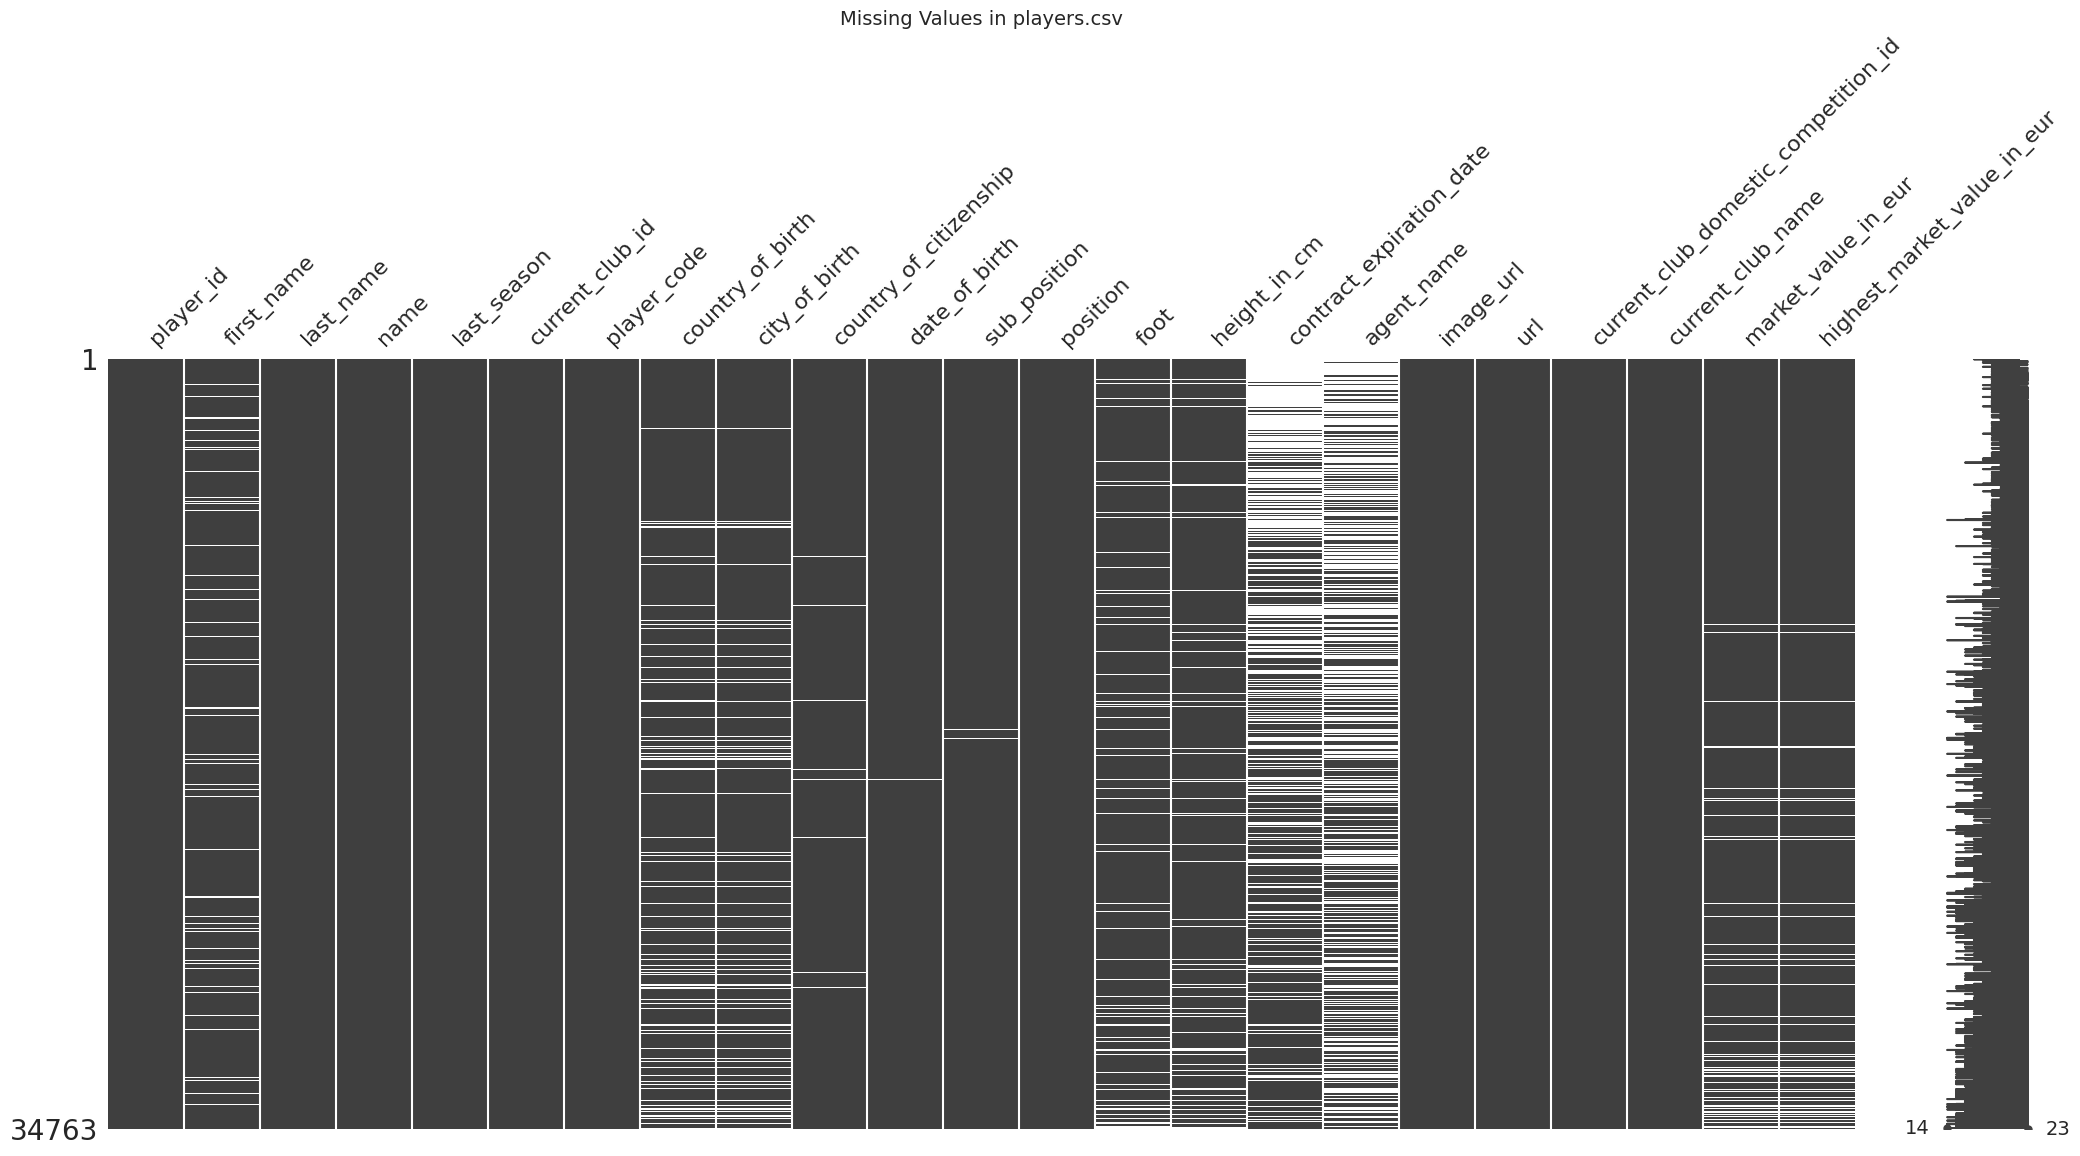

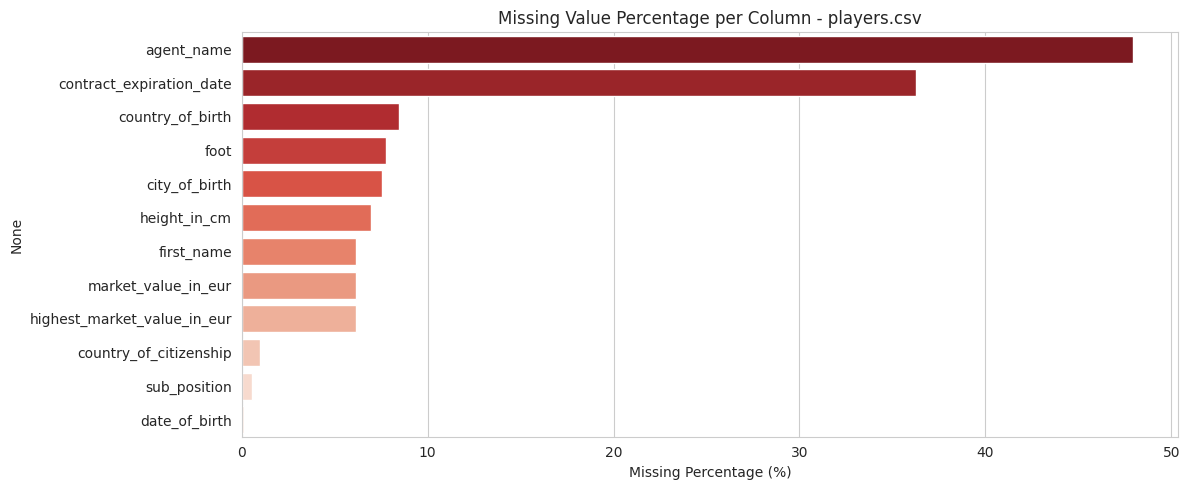

In [153]:
#Missing Value Heatmap and Barchart 

plt.figure(figsize=(14, 6))
msno.matrix(df_players)
plt.title("Missing Values in players.csv", fontsize=14)
plt.tight_layout()
plt.show()

missing_pct = df_players.isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=missing_pct.values, y=missing_pct.index, palette='Reds_r')
plt.xlabel("Missing Percentage (%)")
plt.title("Missing Value Percentage per Column - players.csv")
plt.tight_layout()
plt.show()

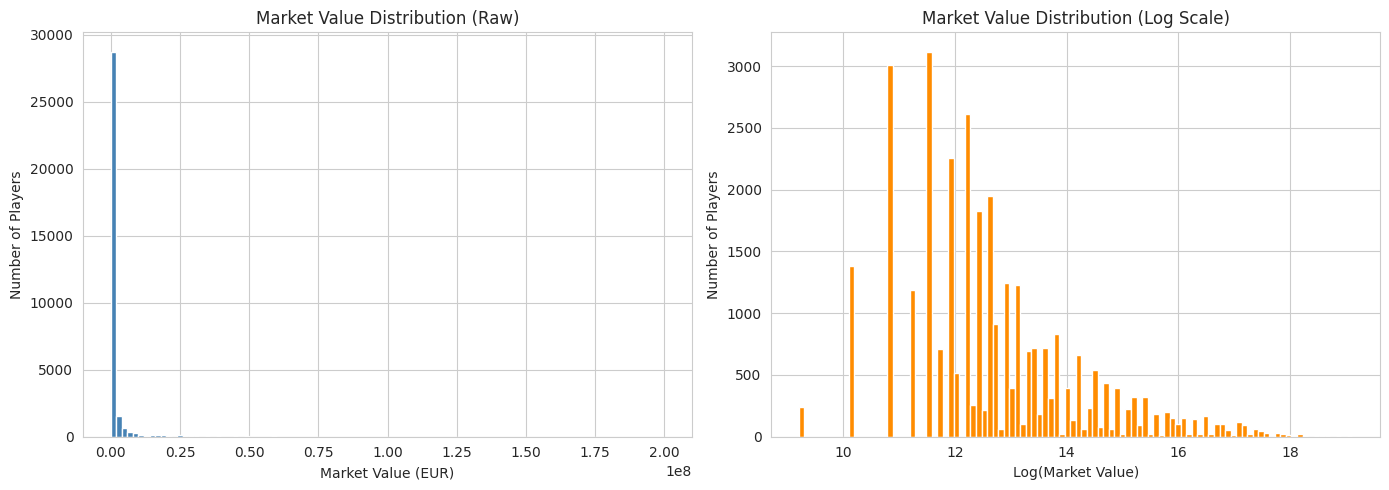

In [154]:
# Distribution of Market Value
df_mv = df_players.dropna(subset=['market_value_in_eur'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(df_mv['market_value_in_eur'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title("Market Value Distribution (Raw)")
axes[0].set_xlabel("Market Value (EUR)")
axes[0].set_ylabel("Number of Players")

# Log distribution (better to visualize skewed data)
axes[1].hist(np.log1p(df_mv['market_value_in_eur']), bins=100, color='darkorange', edgecolor='white')
axes[1].set_title("Market Value Distribution (Log Scale)")
axes[1].set_xlabel("Log(Market Value)")
axes[1].set_ylabel("Number of Players")

plt.tight_layout()
plt.show()

# Note: Market value is heavily right-skewed. Most players have low values while a small number of elite players have extremely high values. Log transformation makes the distribution more normal — this will be useful for the ML model.

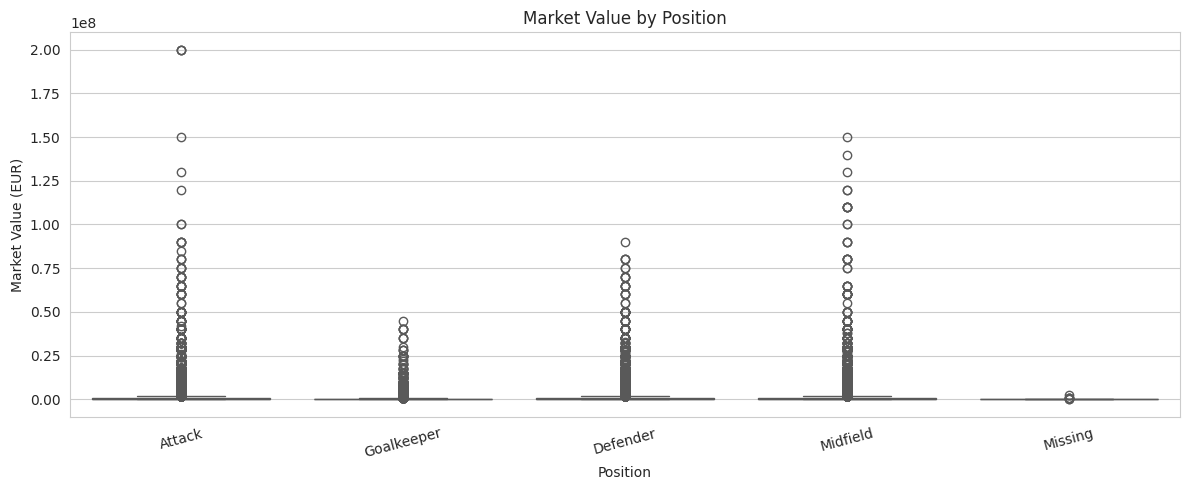

In [155]:
#Market Value by Position

df_pos = df_players.dropna(subset=['market_value_in_eur', 'position'])

plt.figure(figsize=(12, 5))
sns.boxplot(x='position', y='market_value_in_eur', data=df_pos, palette='Set2')
plt.title("Market Value by Position")
plt.xlabel("Position")
plt.ylabel("Market Value (EUR)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#Note: Attackers and midfielders generally command higher market values compared to goalkeepers and defenders.

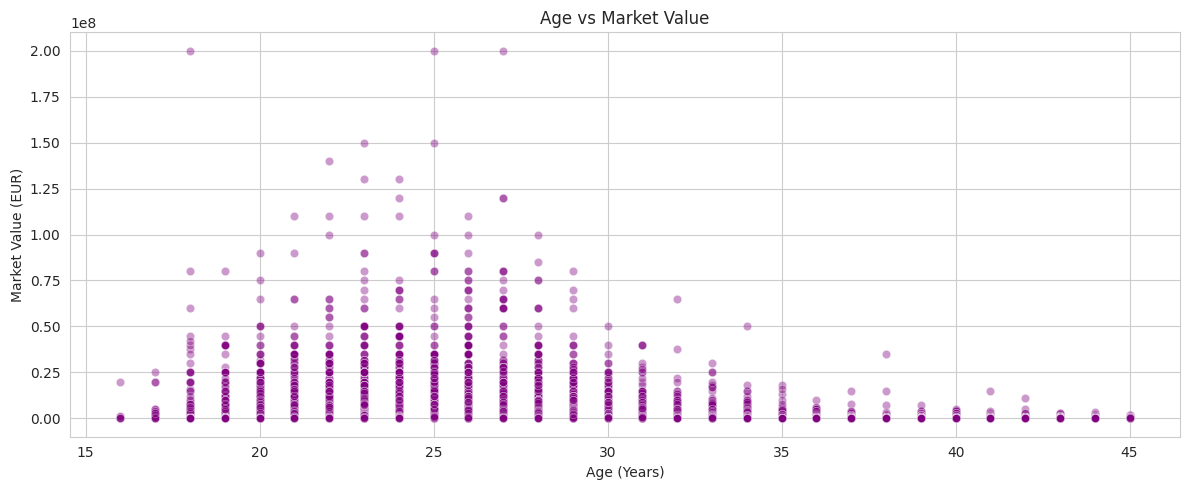

In [156]:
#Age vs Market Value
# Calculate age first
df_players['date_of_birth'] = pd.to_datetime(df_players['date_of_birth'], errors='coerce')
df_players['age'] = (pd.Timestamp.now() - df_players['date_of_birth']).dt.days // 365

df_age = df_players.dropna(subset=['age', 'market_value_in_eur'])
df_age = df_age[(df_age['age'] >= 15) & (df_age['age'] <= 45)]

plt.figure(figsize=(12, 5))
sns.scatterplot(x='age', y='market_value_in_eur', data=df_age, alpha=0.4, color='purple')
plt.title("Age vs Market Value")
plt.xlabel("Age (Years)")
plt.ylabel("Market Value (EUR)")
plt.tight_layout()
plt.show()

#Note: Market value peaks around ages 23–28 and declines significantly after 30. This bell-curve pattern is expected in football.

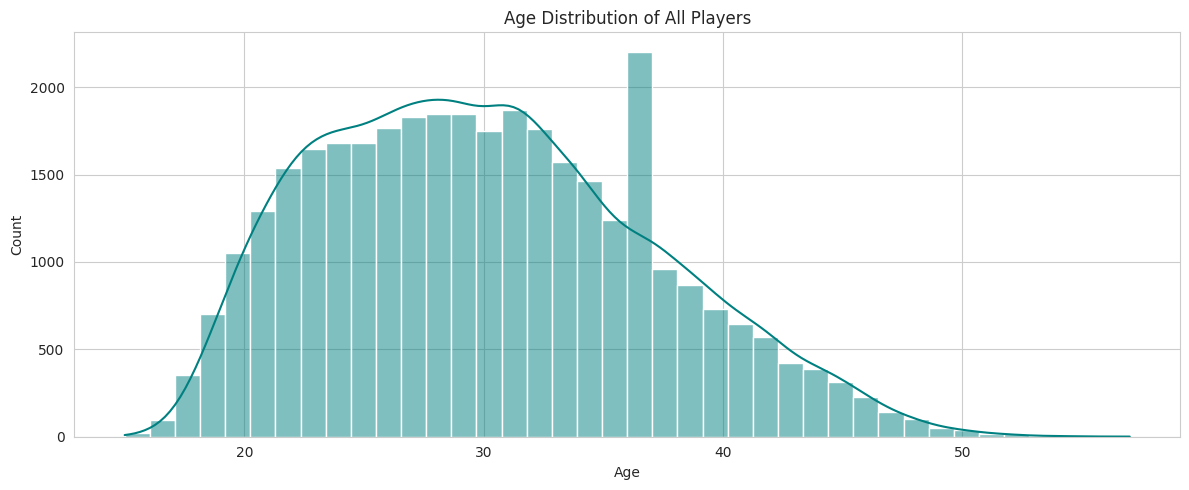

In [157]:
#Age Distribution of Players

plt.figure(figsize=(12, 5))
sns.histplot(df_players['age'].dropna(), bins=40, kde=True, color='teal')
plt.title("Age Distribution of All Players")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

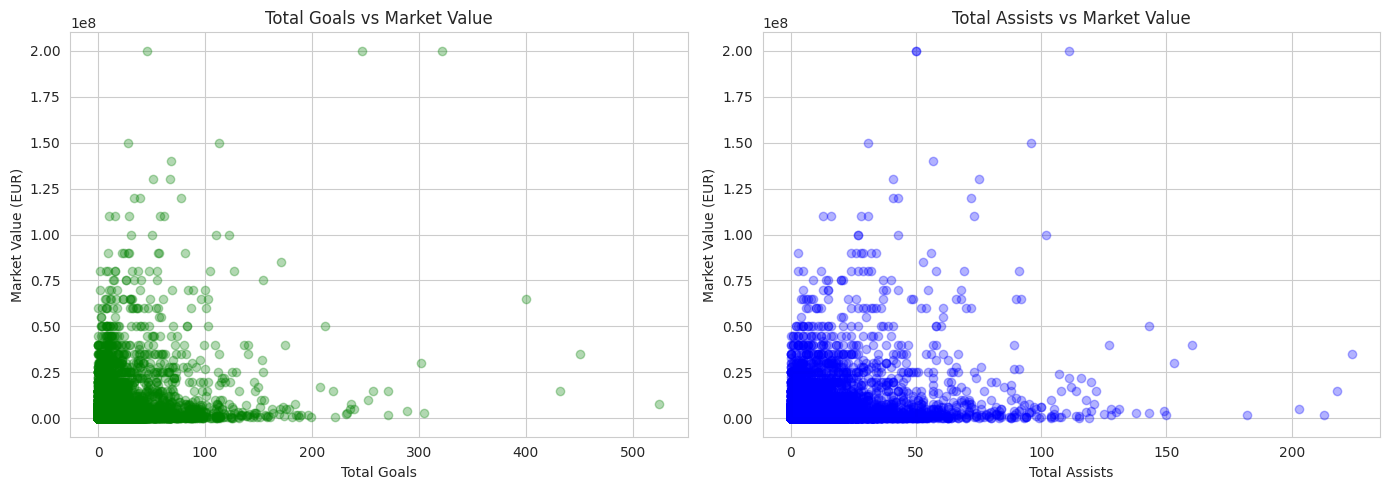

In [158]:
#Goals & Assists vs Market Value

# Aggregate appearances per player
agg = df_appearances.groupby('player_id').agg(
    total_goals=('goals', 'sum'),
    total_assists=('assists', 'sum'),
    total_red_cards=('red_cards', 'sum'),
    total_yellow_cards=('yellow_cards', 'sum'),
    total_minutes=('minutes_played', 'sum')
).reset_index()

# Merge with players
df_merged_temp = df_players.dropna(subset=['market_value_in_eur']).merge(agg, on='player_id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_merged_temp['total_goals'], df_merged_temp['market_value_in_eur'], alpha=0.3, color='green')
axes[0].set_title("Total Goals vs Market Value")
axes[0].set_xlabel("Total Goals")
axes[0].set_ylabel("Market Value (EUR)")

axes[1].scatter(df_merged_temp['total_assists'], df_merged_temp['market_value_in_eur'], alpha=0.3, color='blue')
axes[1].set_title("Total Assists vs Market Value")
axes[1].set_xlabel("Total Assists")
axes[1].set_ylabel("Market Value (EUR)")

plt.tight_layout()
plt.show()

#Note: There is a positive correlation — players with more goals and assists tend to have higher market values, especially strikers and attacking midfielders.

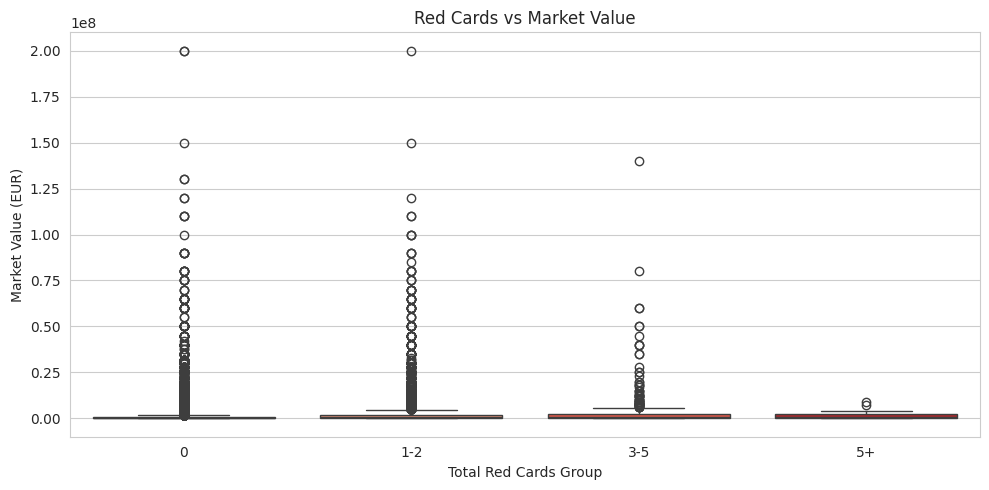

In [159]:

# Red Cards vs Market Value (Grouped Boxplot)
# We group players by how many red cards they have received
# and compare their market values. This shows whether
# disciplinary issues negatively impact a player's value.


plt.figure(figsize=(10, 5))
sns.boxplot(
    x=pd.cut(df_merged_temp['total_red_cards'],
             bins=[-1, 0, 2, 5, 100],
             labels=['0', '1-2', '3-5', '5+']),
    y='market_value_in_eur',
    data=df_merged_temp,
    palette='Reds'
)
plt.title("Red Cards vs Market Value")
plt.xlabel("Total Red Cards Group")
plt.ylabel("Market Value (EUR)")
plt.tight_layout()
plt.show()

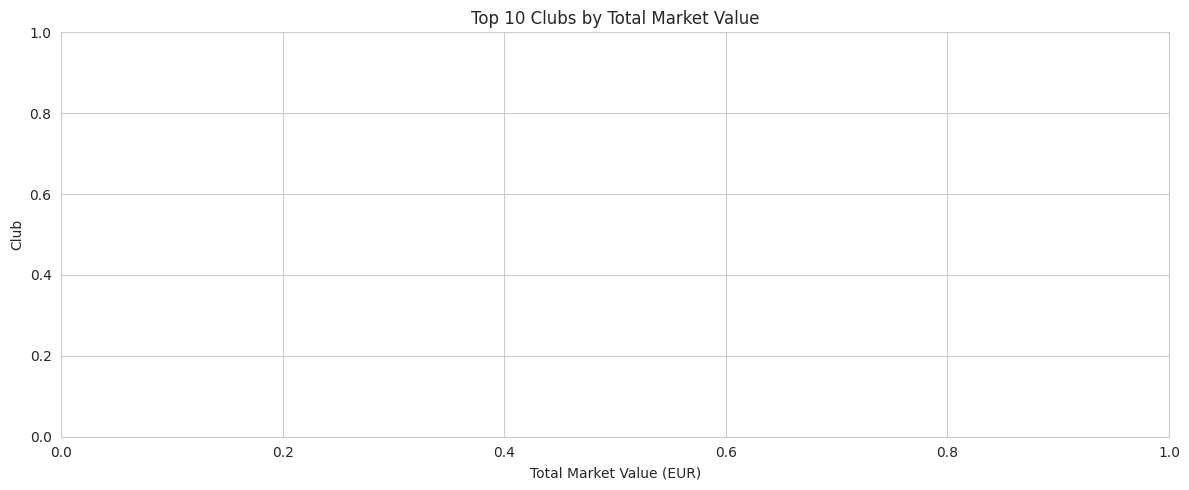

In [160]:

# Top 10 Clubs by Total Squad Market Value
# A horizontal bar chart ranking clubs by combined squad value.
# This helps identify which clubs have the highest quality
# squads and answers our research question about top clubs.


df_clubs_clean_viz = df_clubs.dropna(subset=['total_market_value'])
top_clubs = df_clubs_clean_viz.nlargest(10, 'total_market_value')

plt.figure(figsize=(12, 5))
sns.barplot(x='total_market_value', y='name', data=top_clubs, palette='Blues_r')
plt.title("Top 10 Clubs by Total Market Value")
plt.xlabel("Total Market Value (EUR)")
plt.ylabel("Club")
plt.tight_layout()
plt.show()

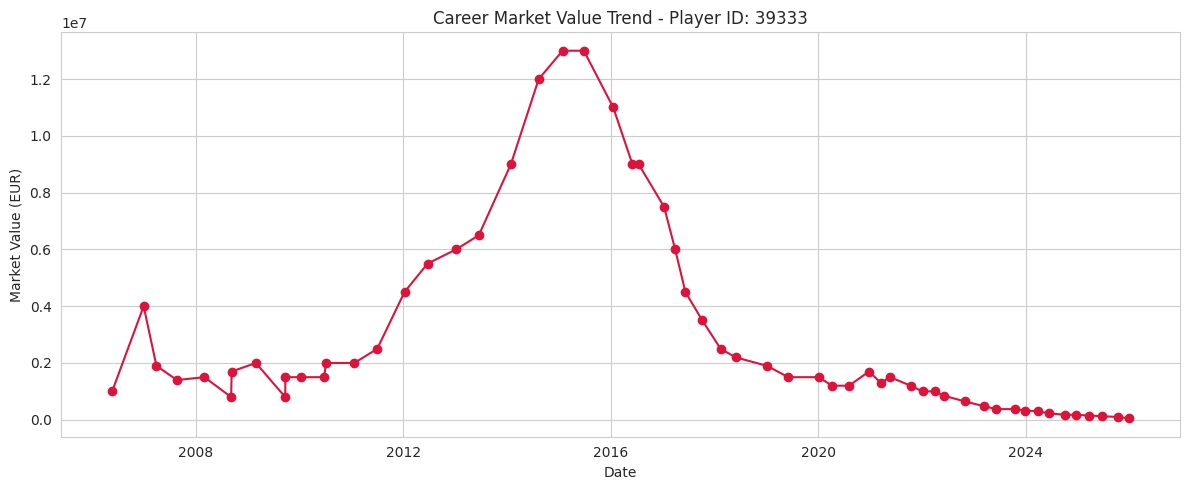

In [161]:

#  Career Market Value Trend for a Single Player
# We pick the player with the most valuation records and plot
# their value over time. This directly answers our research
# question: "How does market value change throughout a career?"


df_valuations['date'] = pd.to_datetime(df_valuations['date'], errors='coerce')

top_player_id = df_valuations['player_id'].value_counts().idxmax()
sample = df_valuations[df_valuations['player_id'] == top_player_id].sort_values('date')

plt.figure(figsize=(12, 5))
plt.plot(sample['date'], sample['market_value_in_eur'], marker='o', color='crimson')
plt.title(f"Career Market Value Trend - Player ID: {top_player_id}")
plt.xlabel("Date")
plt.ylabel("Market Value (EUR)")
plt.tight_layout()
plt.show()

#Note: This plot shows how a single player's market value rises and falls throughout their career — useful for time-series analysis in later phases.

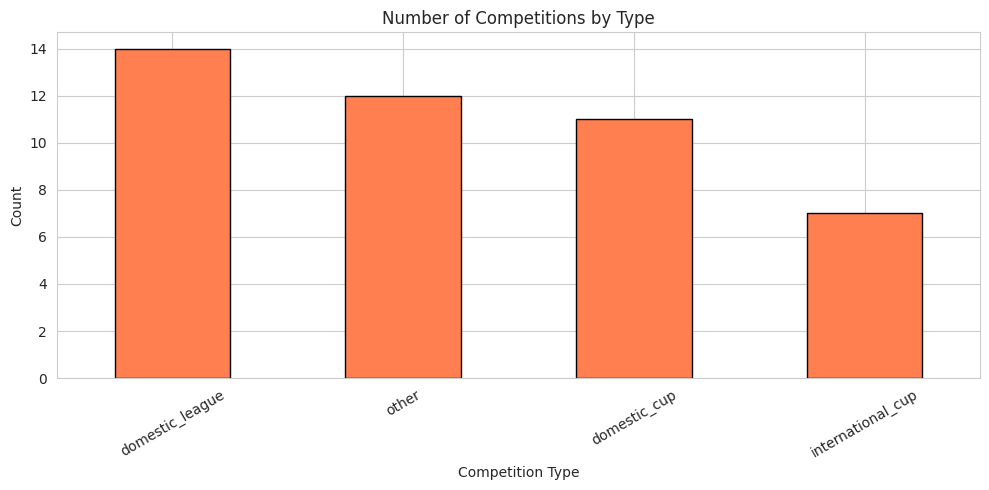

In [162]:
# Number of Competitions by Type
# This bar chart shows how many domestic, international, and
# other competition types exist in the dataset. Helps us
# understand the competition level diversity in our data.

df_comp_clean_viz = df_competitions.dropna(subset=['type'])

plt.figure(figsize=(10, 5))
df_comp_clean_viz['type'].value_counts().plot(kind='bar', color='coral', edgecolor='black')
plt.title("Number of Competitions by Type")
plt.xlabel("Competition Type")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

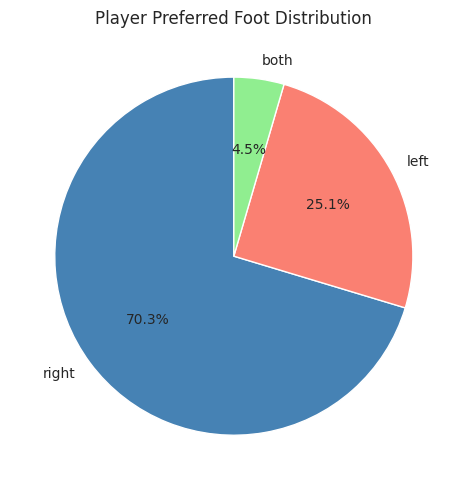

In [163]:
# Player Preferred Foot Distribution (Pie Chart)
# Shows the ratio of right-footed, left-footed and both-footed
# players. Left-footed players are rarer and often valued
# higher — this feature may have ML signal.

plt.figure(figsize=(7, 5))
df_players['foot'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['steelblue', 'salmon', 'lightgreen'],
    startangle=90
)
plt.title("Player Preferred Foot Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

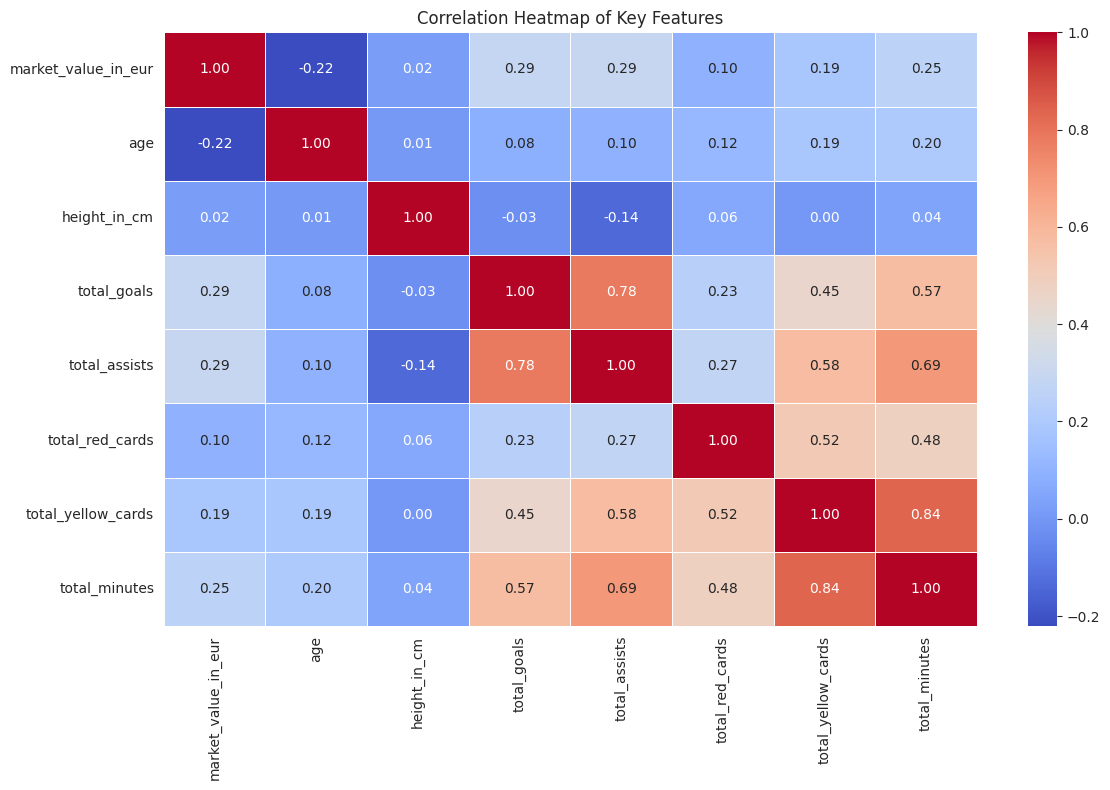

In [164]:
# Correlation Heatmap of All Key Numeric Features
# Shows how strongly each feature is correlated with others
# and with market value. Strong correlations (close to 1 or -1)
# indicate important features for the ML model.
# 

numeric_cols = ['market_value_in_eur', 'age', 'height_in_cm',
                'total_goals', 'total_assists', 'total_red_cards',
                'total_yellow_cards', 'total_minutes']

corr_df = df_merged_temp[numeric_cols].dropna()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Key Features")
plt.tight_layout()
plt.show()

#Note: total_goals, total_assists, and total_minutes show positive correlation with market value. Age shows a moderate relationship.

In [165]:
# Drop Irrelevant Columns from players.csv
# REASON: image_url, url, player_code are web links and system
# identifiers with zero predictive value. first_name and
# last_name are redundant since the 'name' column exists.
# city_of_birth has too many unique values (high cardinality)
# and very little signal for market value prediction.

cols_to_drop = ['first_name', 'last_name', 'player_code',
                'image_url', 'url', 'city_of_birth']

df_players.drop(columns=[c for c in cols_to_drop if c in df_players.columns], inplace=True)

print("Remaining columns in players.csv:")
print(df_players.columns.tolist())

Remaining columns in players.csv:
['player_id', 'name', 'last_season', 'current_club_id', 'country_of_birth', 'country_of_citizenship', 'date_of_birth', 'sub_position', 'position', 'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name', 'current_club_domestic_competition_id', 'current_club_name', 'market_value_in_eur', 'highest_market_value_in_eur', 'age']


In [166]:
# Remove Rows with Missing Market Value
# REASON: market_value_in_eur is our target variable (the value
# we want to predict). Any row without this value is completely
# useless for supervised ML training and must be removed.

before = len(df_players)
df_players.dropna(subset=['market_value_in_eur'], inplace=True)
after = len(df_players)

print(f"Rows before: {before}")
print(f"Rows after:  {after}")
print(f"Rows dropped: {before - after}")

Rows before: 34763
Rows after:  32632
Rows dropped: 2131


In [167]:
# Handle Missing Values in players.csv
# REASON: Columns with >50% missing cannot provide reliable
# information to a model and are dropped. height_in_cm is
# filled with median (not mean) to avoid outlier influence.
# foot and position are filled with mode (most common value)
# since they are categorical columns.

# Drop columns where more than 50% data is missing
threshold = 0.5
cols_before = df_players.shape[1]
df_players = df_players.dropna(thresh=int(len(df_players) * threshold), axis=1)
cols_after = df_players.shape[1]
print(f"Columns dropped due to >50% missing: {cols_before - cols_after}")

# Fill height with median
if 'height_in_cm' in df_players.columns:
    median_height = df_players['height_in_cm'].median()
    df_players['height_in_cm'].fillna(median_height, inplace=True)
    print(f"Filled height_in_cm with median: {median_height}")

# Fill foot with mode
if 'foot' in df_players.columns:
    df_players['foot'].fillna(df_players['foot'].mode()[0], inplace=True)
    print(f"Filled foot with mode: {df_players['foot'].mode()[0]}")

# Fill position with mode
if 'position' in df_players.columns:
    df_players['position'].fillna(df_players['position'].mode()[0], inplace=True)

print("\nRemaining missing values in players.csv:")
print(df_players.isnull().sum()[df_players.isnull().sum() > 0])

Columns dropped due to >50% missing: 0
Filled height_in_cm with median: 183.0
Filled foot with mode: right

Remaining missing values in players.csv:
country_of_birth             2178
country_of_citizenship        324
date_of_birth                  33
sub_position                  105
contract_expiration_date    11667
agent_name                  15381
age                            33
dtype: int64


In [168]:

# Convert date_of_birth Column to Numeric Age
# REASON: ML models cannot process raw date strings. We convert
# date_of_birth into a numeric 'age' feature (in years) which
# the model can directly use. The original date column is then
# dropped since age captures all the needed information.


df_players['date_of_birth'] = pd.to_datetime(df_players['date_of_birth'], errors='coerce')
df_players['age'] = (pd.Timestamp.now() - df_players['date_of_birth']).dt.days // 365
df_players.drop(columns=['date_of_birth'], inplace=True)

print("Age column created successfully. Sample values:")
print(df_players['age'].describe())

Age column created successfully. Sample values:
count    32599.000000
mean        30.553545
std          6.747263
min         16.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         56.000000
Name: age, dtype: float64


In [169]:

# Label Encode Categorical Columns
# REASON: ML algorithms require numeric inputs. Columns like
# position ('Attack', 'Defence'), foot ('Left', 'Right'), and
# country_of_citizenship contain text values. We use Label
# Encoding to convert them to numeric codes the model can use.


from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cat_cols = ['position', 'sub_position', 'foot', 'country_of_citizenship']

for col in cat_cols:
    if col in df_players.columns:
        df_players[col] = df_players[col].astype(str)
        df_players[col + '_encoded'] = le.fit_transform(df_players[col])
        print(f"Encoded: {col}")

print("\nEncoding complete!")

Encoded: position
Encoded: sub_position
Encoded: foot
Encoded: country_of_citizenship

Encoding complete!


In [170]:

# Aggregate Player Performance Stats from appearances.csv
# REASON: appearances.csv has one row per match per player which
# means thousands of rows per player. For ML, we need one row
# per player. We aggregate by summing goals, assists, cards and
# minutes so each player has a single performance summary row.


agg_appearances = df_appearances.groupby('player_id').agg(
    total_goals=('goals', 'sum'),
    total_assists=('assists', 'sum'),
    total_red_cards=('red_cards', 'sum'),
    total_yellow_cards=('yellow_cards', 'sum'),
    total_minutes_played=('minutes_played', 'sum'),
    total_games=('appearance_id', 'count')
).reset_index()

print("Aggregated appearances shape:", agg_appearances.shape)
display(agg_appearances.head())

Aggregated appearances shape: (27355, 7)


,player_id,total_goals,total_assists,total_red_cards,total_yellow_cards,total_minutes_played,total_games
0,10,48,25,0,19,8808,136
1,26,0,0,2,4,13508,152
2,65,38,13,1,11,8788,122
3,77,0,0,0,0,307,4
4,80,0,0,0,0,1080,12


In [171]:

# Clean clubs.csv - Keep Only Relevant Columns
# REASON: We only keep columns that describe club quality and
# prestige which can influence a player's market value.
# Columns like stadium_name, coach_name, url are irrelevant
# to predicting player market value and are dropped.


df_clubs_clean = df_clubs[['club_id', 'name', 'domestic_competition_id',
                             'total_market_value', 'squad_size', 'average_age',
                             'foreigners_percentage', 'national_team_players',
                             'net_transfer_record', 'last_season']].copy()

df_clubs_clean.rename(columns={
    'name': 'club_name',
    'last_season': 'club_last_season'
}, inplace=True)

print("Clubs cleaned shape:", df_clubs_clean.shape)
display(df_clubs_clean.head())

Clubs cleaned shape: (451, 10)


,club_id,club_name,domestic_competition_id,total_market_value,squad_size,average_age,foreigners_percentage,national_team_players,net_transfer_record,club_last_season
0,10,Arminia Bielefeld,L1,NaN,27,25.3,55.6,4,+€5.90m,2021
1,10004,Paris Football Club,FR1,NaN,31,28.5,54.8,9,€-72.30m,2025
2,1003,Leicester City,GB1,NaN,29,25.9,58.6,10,+€57.30m,2024
3,1005,Unione Sportiva Lecce,IT1,NaN,27,25.1,85.2,10,+€8.62m,2025
4,1010,Watford FC,GB1,NaN,30,26.3,80.0,12,+€42.02m,2021


In [172]:

# Clean competitions.csv - Keep Only Relevant Columns
# REASON: We keep league-level features that indicate competition
# prestige such as confederation, country, and whether it is a
# major league. Columns like url and competition_code are system
# identifiers with no value for market value prediction.


df_comp_clean = df_competitions[['competition_id', 'name', 'country_name',
                                   'confederation', 'is_major_national_league', 'type']].copy()

df_comp_clean.rename(columns={'name': 'competition_name'}, inplace=True)

print("Competitions cleaned shape:", df_comp_clean.shape)
display(df_comp_clean.head())

Competitions cleaned shape: (44, 6)


,competition_id,competition_name,country_name,confederation,is_major_national_league,type
0,BE1,jupiler-pro-league,Belgium,europa,False,domestic_league
1,BESC,belgian-supercup,Belgium,europa,False,other
2,CDR,copa-del-rey,Spain,europa,False,domestic_cup
3,CGB,efl-cup,England,europa,False,other
4,CIT,italy-cup,Italy,europa,False,domestic_cup


In [173]:

# Merge All Cleaned Datasets into One Master DataFrame
# REASON: ML models need all features in a single table. We
# join players with performance stats (appearances), club quality
# (clubs), and league prestige (competitions) using player_id,
# club_id and competition_id as foreign keys. Performance NaNs
# are filled with 0 for players who have no appearance records.


df_master = df_players.copy()

# Merge aggregated appearances
df_master = df_master.merge(agg_appearances, on='player_id', how='left')
print(f"After merging appearances: {df_master.shape}")

# Merge clubs info
df_master = df_master.merge(df_clubs_clean, left_on='current_club_id',
                             right_on='club_id', how='left')
print(f"After merging clubs: {df_master.shape}")

# Merge competition info
df_master = df_master.merge(df_comp_clean,
                             left_on='current_club_domestic_competition_id',
                             right_on='competition_id', how='left')
print(f"After merging competitions: {df_master.shape}")

# Fill performance NaN values with 0
perf_cols = ['total_goals', 'total_assists', 'total_red_cards',
             'total_yellow_cards', 'total_minutes_played', 'total_games']
df_master[perf_cols] = df_master[perf_cols].fillna(0)

print("\nFinal Master DataFrame shape:", df_master.shape)
display(df_master.head())

After merging appearances: (32632, 27)
After merging clubs: (32632, 37)
After merging competitions: (32632, 43)

Final Master DataFrame shape: (32632, 43)


,player_id,name,last_season,current_club_id,country_of_birth,country_of_citizenship,sub_position,position,foot,height_in_cm,...,foreigners_percentage,national_team_players,net_transfer_record,club_last_season,competition_id,competition_name,country_name,confederation,is_major_national_league,type
0,10,Miroslav Klose,2015,398,Poland,Germany,Centre-Forward,Attack,right,184.0,...,60.7,12,+€14.07m,2025,IT1,serie-a,Italy,europa,True,domestic_league
1,26,Roman Weidenfeller,2017,16,Germany,Germany,Goalkeeper,Goalkeeper,left,190.0,...,53.8,13,€-23.20m,2025,L1,bundesliga,Germany,europa,True,domestic_league
2,65,Dimitar Berbatov,2015,1091,Bulgaria,Bulgaria,Centre-Forward,Attack,right,183.0,...,58.1,10,€-9.80m,2025,GR1,super-league-1,Greece,europa,False,domestic_league
3,77,Lúcio,2012,506,Brazil,Brazil,Centre-Back,Defender,right,183.0,...,72.0,19,€-49.85m,2025,IT1,serie-a,Italy,europa,True,domestic_league
4,80,Tom Starke,2017,27,East Germany (GDR),Germany,Goalkeeper,Goalkeeper,right,194.0,...,50.0,19,+€12.90m,2025,L1,bundesliga,Germany,europa,True,domestic_league


In [174]:

# Final Summary Check of the Master DataFrame
# We verify the shape, data types, remaining missing values
# and target variable stats before saving to CSV.


print("=" * 60)
print("FINAL MASTER DATAFRAME SUMMARY")
print("=" * 60)
print(f"Shape: {df_master.shape}")
print(f"\nData Types:\n{df_master.dtypes}")
print(f"\nMissing Values:\n{df_master.isnull().sum()[df_master.isnull().sum() > 0]}")
print(f"\nTarget Variable Stats:")
print(df_master['market_value_in_eur'].describe())

FINAL MASTER DATAFRAME SUMMARY
Shape: (32632, 43)

Data Types:
player_id                                 int64
name                                     object
last_season                               int64
current_club_id                           int64
country_of_birth                         object
country_of_citizenship                   object
sub_position                             object
position                                 object
foot                                     object
height_in_cm                            float64
contract_expiration_date                 object
agent_name                               object
current_club_domestic_competition_id     object
current_club_name                        object
market_value_in_eur                     float64
highest_market_value_in_eur             float64
age                                     float64
position_encoded                          int64
sub_position_encoded                      int64
foot_encoded             

In [175]:

# Save the Final Preprocessed Dataset as CSV
# REASON: Saving the cleaned and merged dataset means we do not
# have to repeat all loading, cleaning and merging steps in
# Phase 3. We simply load this one file directly which saves
# significant time and computation in future phases.


df_master.to_csv('preprocessed_player_data.csv', index=False)
print("Preprocessed dataset saved as 'preprocessed_player_data.csv'")
print(f"Final shape: {df_master.shape}")
print(f"Columns saved: {df_master.columns.tolist()}")

Preprocessed dataset saved as 'preprocessed_player_data.csv'
Final shape: (32632, 43)
Columns saved: ['player_id', 'name', 'last_season', 'current_club_id', 'country_of_birth', 'country_of_citizenship', 'sub_position', 'position', 'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name', 'current_club_domestic_competition_id', 'current_club_name', 'market_value_in_eur', 'highest_market_value_in_eur', 'age', 'position_encoded', 'sub_position_encoded', 'foot_encoded', 'country_of_citizenship_encoded', 'total_goals', 'total_assists', 'total_red_cards', 'total_yellow_cards', 'total_minutes_played', 'total_games', 'club_id', 'club_name', 'domestic_competition_id', 'total_market_value', 'squad_size', 'average_age', 'foreigners_percentage', 'national_team_players', 'net_transfer_record', 'club_last_season', 'competition_id', 'competition_name', 'country_name', 'confederation', 'is_major_national_league', 'type']


In [176]:

# Verify the Saved CSV File Loads Correctly
# We reload the saved file and check its shape and top rows
# to confirm everything was saved properly before finishing.


df_check = pd.read_csv('preprocessed_player_data.csv')
print("File loaded successfully!")
print(f"Shape: {df_check.shape}")
display(df_check.head())

File loaded successfully!
Shape: (32632, 43)


,player_id,name,last_season,current_club_id,country_of_birth,country_of_citizenship,sub_position,position,foot,height_in_cm,...,foreigners_percentage,national_team_players,net_transfer_record,club_last_season,competition_id,competition_name,country_name,confederation,is_major_national_league,type
0,10,Miroslav Klose,2015,398,Poland,Germany,Centre-Forward,Attack,right,184.0,...,60.7,12,+€14.07m,2025,IT1,serie-a,Italy,europa,True,domestic_league
1,26,Roman Weidenfeller,2017,16,Germany,Germany,Goalkeeper,Goalkeeper,left,190.0,...,53.8,13,€-23.20m,2025,L1,bundesliga,Germany,europa,True,domestic_league
2,65,Dimitar Berbatov,2015,1091,Bulgaria,Bulgaria,Centre-Forward,Attack,right,183.0,...,58.1,10,€-9.80m,2025,GR1,super-league-1,Greece,europa,False,domestic_league
3,77,Lúcio,2012,506,Brazil,Brazil,Centre-Back,Defender,right,183.0,...,72.0,19,€-49.85m,2025,IT1,serie-a,Italy,europa,True,domestic_league
4,80,Tom Starke,2017,27,East Germany (GDR),Germany,Goalkeeper,Goalkeeper,right,194.0,...,50.0,19,+€12.90m,2025,L1,bundesliga,Germany,europa,True,domestic_league


# FEATURE ENGINEERING 

In [177]:
df_eng = df_master.copy()

# Reset index to make sure player_id is a column not index
df_eng = df_eng.reset_index(drop=True)

# Drop existing perf cols if they already exist from phase 2
existing = ['total_goals', 'total_assists', 'total_red_cards',
            'total_yellow_cards', 'total_minutes_played', 'total_games']
df_eng = df_eng.drop(columns=[c for c in existing if c in df_eng.columns])

# Load appearances fresh
df_appearances = pd.read_csv('/kaggle/input/datasets/davidcariboo/player-scores/appearances.csv')

# Aggregate
agg_appearances = df_appearances.groupby('player_id').agg(
    total_goals=('goals', 'sum'),
    total_assists=('assists', 'sum'),
    total_red_cards=('red_cards', 'sum'),
    total_yellow_cards=('yellow_cards', 'sum'),
    total_minutes_played=('minutes_played', 'sum'),
    total_games=('appearance_id', 'count')
).reset_index()

# Check if player_id exists before merging
if 'player_id' in df_eng.columns:
    df_eng = df_eng.merge(agg_appearances, on='player_id', how='left')
    df_eng[existing] = df_eng[existing].fillna(0)
    print("Merge successful!")
    print(df_eng[existing].head())
else:
    print("player_id not found in df_eng — columns are:")
    print(df_eng.columns.tolist())

Merge successful!
   total_goals  total_assists  total_red_cards  total_yellow_cards  \
0         48.0           25.0              0.0                19.0   
1          0.0            0.0              2.0                 4.0   
2         38.0           13.0              1.0                11.0   
3          0.0            0.0              0.0                 0.0   
4          0.0            0.0              0.0                 0.0   

   total_minutes_played  total_games  
0                8808.0        136.0  
1               13508.0        152.0  
2                8788.0        122.0  
3                 307.0          4.0  
4                1080.0         12.0  


In [178]:
# Aggregate appearances and merge into df_eng
agg_appearances = df_appearances.groupby('player_id').agg(
    total_goals=('goals', 'sum'),
    total_assists=('assists', 'sum'),
    total_red_cards=('red_cards', 'sum'),
    total_yellow_cards=('yellow_cards', 'sum'),
    total_minutes_played=('minutes_played', 'sum'),
    total_games=('appearance_id', 'count')
).reset_index()

df_eng = df_eng.merge(agg_appearances, on='player_id', how='left')

# Fill NaN values with 0 for players with no appearance records
perf_cols = ['total_goals', 'total_assists', 'total_red_cards',
             'total_yellow_cards', 'total_minutes_played', 'total_games']
df_eng[perf_cols] = df_eng[perf_cols].fillna(0)

print("Merge successful!")
print(df_eng[perf_cols].head())

KeyError: "None of [Index(['total_goals', 'total_assists', 'total_red_cards', 'total_yellow_cards',\n       'total_minutes_played', 'total_games'],\n      dtype='object')] are in the [columns]"

In [ ]:
# Install & Import Libraries
df = pd.read_csv('/kaggle/working/preprocessed_player_data.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
display(df.head())
display(df.dtypes)


In [ ]:
df_eng = df_master.copy()

# Load and aggregate appearances
df_appearances = pd.read_csv('/kaggle/input/datasets/davidcariboo/player-scores/appearances.csv')
agg_appearances = df_appearances.groupby('player_id').agg(
    total_goals=('goals', 'sum'),
    total_assists=('assists', 'sum'),
    total_red_cards=('red_cards', 'sum'),
    total_yellow_cards=('yellow_cards', 'sum'),
    total_minutes_played=('minutes_played', 'sum'),
    total_games=('appearance_id', 'count')
).reset_index()

# Drop existing performance cols if they already exist to avoid duplicates
existing = ['total_goals', 'total_assists', 'total_red_cards', 
            'total_yellow_cards', 'total_minutes_played', 'total_games']
df_eng = df_eng.drop(columns=[c for c in existing if c in df_eng.columns])

# Merge aggregated appearances
df_eng = df_eng.merge(agg_appearances, on='player_id', how='left')
df_eng[existing] = df_eng[existing].fillna(0)

# Load and merge age
df_players_raw = pd.read_csv('/kaggle/input/datasets/davidcariboo/player-scores/players.csv')
df_players_raw['date_of_birth'] = pd.to_datetime(df_players_raw['date_of_birth'], errors='coerce')
df_players_raw['age'] = (pd.Timestamp.now() - df_players_raw['date_of_birth']).dt.days // 365

if 'age' in df_eng.columns:
    df_eng = df_eng.drop(columns=['age'])

df_eng = df_eng.merge(df_players_raw[['player_id', 'age']], on='player_id', how='left')

print("Ready! Shape:", df_eng.shape)
print(df_eng[existing + ['age']].head())

In [ ]:

# Quick Data Sanity Check
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nTarget variable (market_value_in_eur) stats:")
print(df['market_value_in_eur'].describe())

In [ ]:
# Prepare Base Feature Set for Importance Analysis
# We select only numeric columns and drop leakage columns.
# highest_market_value is dropped because it directly reveals
# the target and would cause data leakage in the model.


drop_cols = ['player_id', 'club_id', 'competition_id',
             'current_club_id', 'current_club_domestic_competition_id',
             'highest_market_value_in_eur',  # leakage
             'name', 'player_name', 'club_name', 'competition_name',
             'country_of_citizenship', 'position', 'sub_position',
             'foot', 'country_name', 'confederation', 'type']

df_model = df.copy()
df_model = df_model.drop(columns=[c for c in drop_cols if c in df_model.columns])
df_model = df_model.select_dtypes(include=[np.number])
df_model = df_model.dropna(subset=['market_value_in_eur'])
df_model = df_model.fillna(df_model.median(numeric_only=True))

X = df_model.drop(columns=['market_value_in_eur'])
y = df_model['market_value_in_eur']

print(f"Feature matrix shape: {X.shape}")
print(f"Features used:\n{X.columns.tolist()}")


In [ ]:
# Train/Test Split (Used Across All Algorithms)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")


# FEATURE IMPORTANCE (5 ALGORITHMS)


In [ ]:
 # Algorithm 1 — Random Forest Feature Importance
# Random Forest ranks features by how much each one reduces
# impurity across all decision trees in the forest.


rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
rf_importance.head(20).plot(kind='bar', color='steelblue')
plt.title("Algorithm 1: Random Forest - Feature Importance")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 10 Features (Random Forest):")
print(rf_importance.head(10))


In [ ]:
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

In [ ]:
# Gradient Boosting Feature Importance
# Gradient Boosting builds trees sequentially. Each tree
# corrects the error of the previous one. Feature importance
# is measured by how much each feature reduces the loss.

gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

gb_importance = pd.Series(gb.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
gb_importance.head(20).plot(kind='bar', color='darkorange')
plt.title("Algorithm 2: Gradient Boosting - Feature Importance")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 10 Features (Gradient Boosting):")
print(gb_importance.head(10))


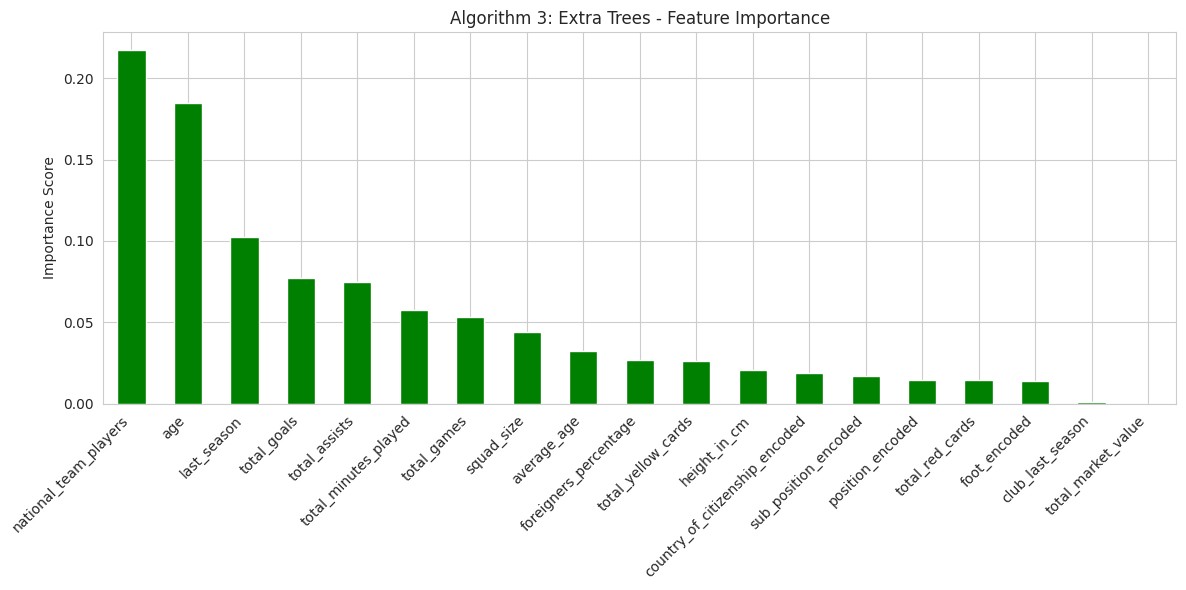

Top 10 Features (Extra Trees):
national_team_players    0.217346
age                      0.184754
last_season              0.102494
total_goals              0.077461
total_assists            0.075050
total_minutes_played     0.057703
total_games              0.053528
squad_size               0.044361
average_age              0.032562
foreigners_percentage    0.026930
dtype: float64


In [179]:
# Algorithm 3 — Extra Trees Feature Importance
# Extra Trees is similar to Random Forest but uses random
# splits instead of best splits, making it faster and often
# giving different importance rankings than Random Forest.

et = ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1)
et.fit(X_train, y_train)

et_importance = pd.Series(et.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
et_importance.head(20).plot(kind='bar', color='green')
plt.title("Algorithm 3: Extra Trees - Feature Importance")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 10 Features (Extra Trees):")
print(et_importance.head(10))


In [189]:
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())
y_train = y_train.fillna(y_train.median())
y_test = y_test.fillna(y_test.median())

print("NaN values removed from train and test sets!")

NaN values removed from train and test sets!


In [196]:
# Algorithm 4 — LASSO Regression Feature Importance
# LASSO adds a penalty that shrinks less useful feature
# coefficients to exactly zero, effectively removing them.
# Features with non-zero coefficients are the most important.

from sklearn.preprocessing import StandardScaler

scaler_lasso = StandardScaler()
X_train_scaled = scaler_lasso.fit_transform(X_train)
X_test_scaled  = scaler_lasso.transform(X_test)

lasso = Lasso(alpha=1000, max_iter=10000, random_state=42)
lasso.fit(X_train_scaled, y_train)

lasso_importance = pd.Series(np.abs(lasso.coef_), index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
lasso_importance.head(20).plot(kind='bar', color='purple')
plt.title("Algorithm 4: LASSO - Feature Importance (Absolute Coefficients)")
plt.ylabel("Absolute Coefficient")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 10 Features (LASSO):")
print(lasso_importance.head(10))


ValueError: Input X contains NaN.
Lasso does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

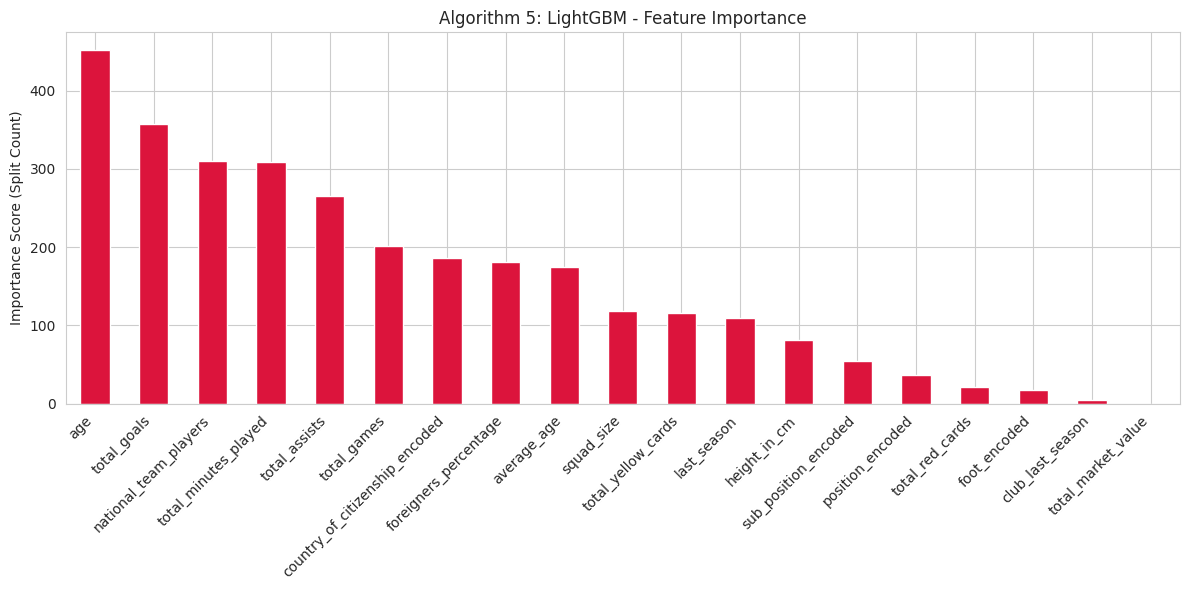

Top 10 Features (LightGBM):
age                               452
total_goals                       357
national_team_players             310
total_minutes_played              309
total_assists                     266
total_games                       202
country_of_citizenship_encoded    186
foreigners_percentage             181
average_age                       175
squad_size                        118
dtype: int32


In [182]:
# Algorithm 5 — LightGBM Feature Importance
# LightGBM is a fast gradient boosting framework. It measures
# importance by how many times a feature is used to split data
# across all trees (split count method).


lgbm = LGBMRegressor(random_state=42, verbose=-1)
lgbm.fit(X_train, y_train)

lgbm_importance = pd.Series(lgbm.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
lgbm_importance.head(20).plot(kind='bar', color='crimson')
plt.title("Algorithm 5: LightGBM - Feature Importance")
plt.ylabel("Importance Score (Split Count)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 10 Features (LightGBM):")
print(lgbm_importance.head(10))


In [197]:
# Summary — Combined Feature Importance Ranking
# We average the normalized importance scores from all 5
# algorithms to get a final consensus ranking of features.


def normalize_series(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

combined = pd.DataFrame({
    'RandomForest':     normalize_series(rf_importance),
    'GradientBoosting': normalize_series(gb_importance),
    'ExtraTrees':       normalize_series(et_importance),
    'LASSO':            normalize_series(lasso_importance),
    'LightGBM':         normalize_series(lgbm_importance),
})

combined['avg_score'] = combined.mean(axis=1)
combined = combined.sort_values('avg_score', ascending=False)

plt.figure(figsize=(12, 6))
combined['avg_score'].head(20).plot(kind='bar', color='teal')
plt.title("Combined Average Feature Importance (All 5 Algorithms)")
plt.ylabel("Normalized Average Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 15 Features by Combined Score:")
display(combined.head(15))


NameError: name 'gb_importance' is not defined

# SHAP & LIME EXPLAINABILITY


In [ ]:
# SHAP Values — Global Feature Importance
# SHAP (SHapley Additive exPlanations) assigns each feature
# a contribution value for each prediction. It is the most
# theoretically sound method for explaining model predictions.
# We use the LightGBM model since SHAP supports it natively.


explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP - Global Feature Importance (Bar)")
plt.tight_layout()
plt.show()

plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP - Feature Impact on Predictions (Beeswarm)")
plt.tight_layout()
plt.show()



In [ ]:
# LIME — Local Feature Importance for One Player
# LIME (Local Interpretable Model-Agnostic Explanations)
# explains a single prediction by fitting a simple linear
# model around that specific data point. It shows which
# features pushed that one player's value up or down.


lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns.tolist(),
    mode='regression'
)

# Explain prediction for the first player in test set
lime_exp = lime_explainer.explain_instance(
    data_row=np.array(X_test.iloc[0]),
    predict_fn=lgbm.predict,
    num_features=10
)

print("LIME Explanation for Player at index 0 (Test Set):")
lime_exp.as_pyplot_figure()
plt.title("LIME - Local Feature Importance for One Player")
plt.tight_layout()
plt.show()


In [ ]:
# Load Clean Copy and Start Engineering New Features
df_eng = df.copy()
df_eng = df_eng.fillna(df_eng.median(numeric_only=True))
print(f"Working dataset shape: {df_eng.shape}")


In [ ]:
# New Feature 1 — Goals Per Game
# Goals per game normalizes total goals by games played.
# A player with 10 goals in 15 games is more efficient
# than one with 12 goals in 40 games. This better reflects
# a player's true scoring ability regardless of game count.
df_eng['goals_per_game'] = df_eng['total_goals'] / (df_eng['total_games'] + 1e-9)
print(df_eng['goals_per_game'].describe())

In [ ]:
# New Feature 2 — Assists Per Game
# Assists per game captures creative output per match.
# Important for valuing midfielders and wingers accurately
# without being biased by how many total games they played.
df_eng['assists_per_game'] = df_eng['total_assists'] / (df_eng['total_games'] + 1e-9)
print(df_eng['assists_per_game'].describe())

In [ ]:
# New Feature 3 — Goal Contributions Per Game
# Combines goals and assists into one efficiency metric per game.
# Used by scouts worldwide to measure overall attacking output.
# More informative than goals or assists alone.
df_eng['goal_contributions_per_game'] = (
    (df_eng['total_goals'] + df_eng['total_assists']) / (df_eng['total_games'] + 1e-9)
)
print(df_eng['goal_contributions_per_game'].describe())

In [ ]:
# New Feature 4 — Disciplinary Score
# Red cards are 3x more impactful than yellow cards since
# they lead to suspensions. This weighted score captures
# a player's disciplinary risk which negatively affects value.
df_eng['disciplinary_score'] = (
    df_eng['total_yellow_cards'] * 1 + df_eng['total_red_cards'] * 3
)
print(df_eng['disciplinary_score'].describe())

In [ ]:
# New Feature 5 — Minutes Per Game
# A player who plays 90 minutes every game is a guaranteed
# starter and far more valuable than a substitute. This
# captures how central a player is to their team's strategy.
df_eng['minutes_per_game'] = df_eng['total_minutes_played'] / (df_eng['total_games'] + 1e-9)
print(df_eng['minutes_per_game'].describe())

In [ ]:
# New Feature 6 — Peak Age Flag
# Football research shows players peak between ages 24 and 28.
# This binary flag directly captures whether a player is in
# their prime years which strongly drives maximum market value.
df_eng['is_peak_age'] = df_eng['age'].apply(lambda x: 1 if 24 <= x <= 28 else 0)
print("Peak age players:", df_eng['is_peak_age'].sum())


In [ ]:
# New Feature 7 — Age Squared
# The relationship between age and value is not linear.
# It rises then falls like a curve. Age squared lets the
# model capture this non-linear career arc that a simple
# age feature alone cannot express.
df_eng['age_squared'] = df_eng['age'] ** 2
print(df_eng['age_squared'].describe())

In [ ]:

# New Feature 8 — Performance Score
# A single composite score combining goals, assists and
# minutes into one weighted metric. Summarizes a player's
# overall on-pitch contribution in one number efficiently.
df_eng['performance_score'] = (
    df_eng['total_goals'] * 3 +
    df_eng['total_assists'] * 2 +
    df_eng['total_minutes_played'] * 0.01
)
print(df_eng['performance_score'].describe())

In [ ]:
# New Feature 9 — Club Value Per Player
# Normalizes club wealth by squad size. Indicates the average
# investment per player at a club. Players at wealthier clubs
# per capita tend to have higher individual market values.
df_eng['club_value_per_player'] = df_eng['total_market_value'] / (df_eng['squad_size'] + 1e-9)
print(df_eng['club_value_per_player'].describe())

In [ ]:
# New Feature 10 — Is Major League Flag
# Playing in a major league boosts visibility and therefore
# market value significantly. This binary flag captures
# league prestige as a direct feature for the model.
if 'is_major_national_league' in df_eng.columns:
    df_eng['is_major_league'] = df_eng['is_major_national_league'].fillna(0).astype(int)
else:
    df_eng['is_major_league'] = 0
print("Major league players:", df_eng['is_major_league'].sum())

In [ ]:
# New Feature 11 — Log Market Value
# Market value is heavily right-skewed. Log transformation
# makes it more normally distributed which helps regression
# models learn better. This will be the training target.
df_eng['log_market_value'] = np.log1p(df_eng['market_value_in_eur'])

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df_eng['market_value_in_eur'], bins=100, color='steelblue')
plt.title("Original Market Value Distribution")

plt.subplot(1, 2, 2)
plt.hist(df_eng['log_market_value'], bins=100, color='darkorange')
plt.title("Log-Transformed Market Value Distribution")
plt.tight_layout()
plt.show()

In [ ]:
# Create all new features at once
df_eng['goals_per_game'] = df_eng['total_goals'] / (df_eng['total_games'] + 1e-9)
df_eng['assists_per_game'] = df_eng['total_assists'] / (df_eng['total_games'] + 1e-9)
df_eng['goal_contributions_per_game'] = (df_eng['total_goals'] + df_eng['total_assists']) / (df_eng['total_games'] + 1e-9)
df_eng['disciplinary_score'] = df_eng['total_yellow_cards'] * 1 + df_eng['total_red_cards'] * 3
df_eng['minutes_per_game'] = df_eng['total_minutes_played'] / (df_eng['total_games'] + 1e-9)
df_eng['is_peak_age'] = df_eng['age'].apply(lambda x: 1 if 24 <= x <= 28 else 0)
df_eng['age_squared'] = df_eng['age'] ** 2
df_eng['performance_score'] = (df_eng['total_goals'] * 3 + df_eng['total_assists'] * 2 + df_eng['total_minutes_played'] * 0.01)
df_eng['club_value_per_player'] = df_eng['total_market_value'] / (df_eng['squad_size'] + 1e-9)
df_eng['is_major_league'] = df_eng['is_major_national_league'].fillna(0).astype(int) if 'is_major_national_league' in df_eng.columns else 0
df_eng['log_market_value'] = np.log1p(df_eng['market_value_in_eur'])

print("All new features created!")
print(df_eng[['goals_per_game', 'assists_per_game', 'goal_contributions_per_game',
              'disciplinary_score', 'minutes_per_game', 'is_peak_age',
              'age_squared', 'performance_score', 'club_value_per_player',
              'is_major_league', 'log_market_value']].head())

In [ ]:
# Prepare train/test split for new features
new_features = [
    'goals_per_game', 'assists_per_game', 'goal_contributions_per_game',
    'disciplinary_score', 'minutes_per_game', 'is_peak_age',
    'age_squared', 'performance_score', 'club_value_per_player', 'is_major_league'
]

base_features = [col for col in X.columns if col in df_eng.columns]
all_features = base_features + new_features

df_feat = df_eng[all_features + ['market_value_in_eur']].dropna()

X_new = df_feat[all_features]
y_new = df_feat['market_value_in_eur']

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42
)

print(f"X_train_new shape: {X_train_new.shape}")
print(f"X_test_new shape: {X_test_new.shape}")

In [ ]:
# LightGBM Before vs After Feature Engineering
lgbm_before = LGBMRegressor(random_state=42, verbose=-1)
lgbm_before.fit(X_train, y_train)
pred_before = lgbm_before.predict(X_test)
r2_before   = r2_score(y_test, pred_before)
rmse_before = np.sqrt(mean_squared_error(y_test, pred_before))

lgbm_after = LGBMRegressor(random_state=42, verbose=-1)
lgbm_after.fit(X_train_new, y_train_new)
pred_after = lgbm_after.predict(X_test_new)
r2_after   = r2_score(y_test_new, pred_after)
rmse_after = np.sqrt(mean_squared_error(y_test_new, pred_after))

print("=" * 50)
print("LightGBM Performance Comparison")
print("=" * 50)
print(f"BEFORE Feature Engineering — R2: {r2_before:.4f} | RMSE: {rmse_before:,.0f}")
print(f"AFTER  Feature Engineering — R2: {r2_after:.4f}  | RMSE: {rmse_after:,.0f}")
print("=" * 50)

In [ ]:
# Feature Importance After Engineering
new_importance = pd.Series(
    lgbm_after.feature_importances_, index=X_new.columns
).sort_values(ascending=False)

plt.figure(figsize=(14, 6))
new_importance.head(25).plot(kind='bar', color='teal')
plt.title("LightGBM Feature Importance After Engineering")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Feature Importance After Engineering

In [ ]:
# Feature Importance After Engineering
new_importance = pd.Series(
    lgbm_after.feature_importances_, index=X_new.columns
).sort_values(ascending=False)

plt.figure(figsize=(14, 6))
new_importance.head(25).plot(kind='bar', color='teal')
plt.title("LightGBM Feature Importance After Engineering")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Drop Low Importance Features
# Features with near-zero importance are dropped because they
# are never used by the model in any splits. They add no
# predictive value and may introduce noise into the model.
threshold_importance = 10
low_importance_features = new_importance[new_importance < threshold_importance].index.tolist()

print(f"Features dropped (importance < {threshold_importance}):")
print(low_importance_features)

X_new_reduced = X_new.drop(columns=low_importance_features, errors='ignore')

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_new_reduced, y_new, test_size=0.2, random_state=42
)

lgbm_reduced = LGBMRegressor(random_state=42, verbose=-1)
lgbm_reduced.fit(X_train_r, y_train_r)
pred_reduced = lgbm_reduced.predict(X_test_r)

r2_reduced   = r2_score(y_test_r, pred_reduced)
rmse_reduced = np.sqrt(mean_squared_error(y_test_r, pred_reduced))
print(f"After Dropping Low Importance — R2: {r2_reduced:.4f} | RMSE: {rmse_reduced:,.0f}")


# STANDARDIZATION & NORMALIZATION


In [ ]:
# Standardize Features Using StandardScaler
# StandardScaler transforms features to mean=0 and std=1.
# Required for distance-based models like KMeans and linear
# models like LASSO. Does not hurt tree-based models either.
scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X_new_reduced),
    columns=X_new_reduced.columns
)

print("Standardization complete!")
print(f"Mean of features (should be ~0):\n{X_scaled.mean().round(4)}")
print(f"Std of features (should be ~1):\n{X_scaled.std().round(4)}")


In [ ]:
# Verify Scaled Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
X_new_reduced['total_goals'].hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title("Before Scaling: total_goals")
X_scaled['total_goals'].hist(bins=50, ax=axes[1], color='darkorange')
axes[1].set_title("After Scaling: total_goals (Standardized)")
plt.tight_layout()
plt.show()

In [ ]:
# Find Optimal K Using Elbow Method
inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker='o', color='crimson')
plt.title("Elbow Method — Optimal Number of Clusters (K)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.tight_layout()
plt.show()

In [ ]:
# Apply K-Means and Create Player Tier Feature
# K-Means groups players into tiers based on their overall
# stats profile. The cluster label becomes a new feature
# called player_tier which encodes whether a player is elite,
# mid-tier or lower-tier. This captures group-level patterns
# the model would otherwise miss from individual features alone.
best_k = 4

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

X_new_reduced = X_new_reduced.copy()
X_new_reduced['player_tier'] = cluster_labels

print(f"K-Means applied with K={best_k}")
print(f"Cluster distribution:\n{pd.Series(cluster_labels).value_counts().sort_index()}")

In [ ]:
# Visualize Player Tiers vs Market Value
plot_df = X_new_reduced.copy()
plot_df['market_value_in_eur'] = y_new.values

plt.figure(figsize=(10, 5))
sns.boxplot(x='player_tier', y='market_value_in_eur', data=plot_df, palette='Set2')
plt.title("Market Value by Player Tier (K-Means Cluster)")
plt.xlabel("Player Tier (Cluster)")
plt.ylabel("Market Value (EUR)")
plt.tight_layout()
plt.show()

In [ ]:
# Test LightGBM with player_tier Feature
X_final = X_new_reduced.copy()
y_final = y_new.copy()

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42
)

lgbm_final = LGBMRegressor(random_state=42, verbose=-1)
lgbm_final.fit(X_train_f, y_train_f)
pred_final = lgbm_final.predict(X_test_f)

r2_final   = r2_score(y_test_f, pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test_f, pred_final))
print("=" * 60)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 60)
print(f"Original Features Only     — R2: {r2_before:.4f} | RMSE: {rmse_before:,.0f}")
print(f"After Feature Engineering  — R2: {r2_after:.4f}  | RMSE: {rmse_after:,.0f}")
print(f"After Dropping Low Imp.    — R2: {r2_reduced:.4f} | RMSE: {rmse_reduced:,.0f}")
print(f"With K-Means Tier Feature  — R2: {r2_final:.4f}  | RMSE: {rmse_final:,.0f}")
print("=" * 60)

In [ ]:
# Final Feature Importance After All Engineering
final_importance = pd.Series(
    lgbm_final.feature_importances_, index=X_final.columns
).sort_values(ascending=False)

plt.figure(figsize=(14, 6))
final_importance.plot(kind='bar', color='navy')
plt.title("Final Feature Importance After All Engineering Steps")
plt.ylabel("LightGBM Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Final features used:")
print(X_final.columns.tolist())

In [ ]:
# Save Final Engineered Dataset as CSV
# This file will be loaded directly in Phase 4 without
# repeating any feature engineering steps, saving time.
df_save = X_final.copy()
df_save['market_value_in_eur'] = y_final.values
df_save['log_market_value']    = np.log1p(df_save['market_value_in_eur'])

df_save.to_csv('feature_engineered_player_data.csv', index=False)

print("Saved as 'feature_engineered_player_data.csv'")
print(f"Shape: {df_save.shape}")
print(f"Columns: {df_save.columns.tolist()}")

In [ ]:
# Verify Saved File
df_verify = pd.read_csv('feature_engineered_player_data.csv')
print("File verified successfully!")
print(f"Shape: {df_verify.shape}")
display(df_verify.head())